In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
# importing train and test files
train= pd.read_csv("/kaggle/input/spaceship-titanic/train.csv")
test= pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")

In [3]:
train

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [4]:
test

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


In [5]:
print(train.shape)
print(test.shape)

(8693, 14)
(4277, 13)


In [6]:
# checking for null values
print(train.isnull().sum())
print("\n")
print(print(test.isnull().sum()))

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64
None


In [7]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [8]:
train.describe(include=object)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
count,8693,8492,8476,8494,8511,8490,8493
unique,8693,3,2,6560,3,2,8473
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,False,Gollux Reedall
freq,1,4602,5439,8,5915,8291,2


In [9]:
test.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4186.000000,4195.000000,4171.000000,4179.000000,4176.000000,4197.000000
mean,28.658146,219.266269,439.484296,177.295525,303.052443,310.710031
std,14.179072,607.011289,1527.663045,560.821123,1117.186015,1246.994742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,53.000000,78.000000,33.000000,50.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


In [10]:
test.describe(include=object)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
count,4277,4190,4184,4177,4185,4184,4183
unique,4277,3,2,3265,3,2,4176
top,0013_01,Earth,False,G/160/P,TRAPPIST-1e,False,Cints Erle
freq,1,2263,2640,8,2956,4110,2


In [11]:
# from this i see that categorical data is present, now categories dekhne ke lie:
# in test data
print("HomePlanet categories\n")
print(test['HomePlanet'].unique())
print(test['HomePlanet'].value_counts())

print("\n")
print("CryoSleep categories\n")
print(test['CryoSleep'].unique())
print(test['CryoSleep'].value_counts())

print("\n")
print("Destination categories\n")
print(test['Destination'].unique())
print(test['Destination'].value_counts())

print("\n")
print("VIP categories\n")
print(test['VIP'].unique())
print(test['VIP'].value_counts())

HomePlanet categories

['Earth' 'Europa' 'Mars' nan]
HomePlanet
Earth     2263
Europa    1002
Mars       925
Name: count, dtype: int64


CryoSleep categories

[True False nan]
CryoSleep
False    2640
True     1544
Name: count, dtype: int64


Destination categories

['TRAPPIST-1e' '55 Cancri e' 'PSO J318.5-22' nan]
Destination
TRAPPIST-1e      2956
55 Cancri e       841
PSO J318.5-22     388
Name: count, dtype: int64


VIP categories

[False nan True]
VIP
False    4110
True       74
Name: count, dtype: int64


In [12]:
# handling missing values

In [13]:
# in train data
# general stuff
train["RoomService"]=train["RoomService"].fillna(train["RoomService"].median())
train["FoodCourt"]=train["FoodCourt"].fillna(train["FoodCourt"].median())
train["ShoppingMall"]=train["ShoppingMall"].fillna(train["ShoppingMall"].median())
train["Spa"]=train["Spa"].fillna(train["Spa"].median())
train["VRDeck"]=train["VRDeck"].fillna(train["VRDeck"].median())
# categorical stuff
train["HomePlanet"]=train["HomePlanet"].fillna(train["HomePlanet"].mode())
train["CryoSleep"]=train["CryoSleep"].fillna(train["CryoSleep"].mode())
train["Destination"]=train["Destination"].fillna(train["Destination"].mode())
train["VIP"]=train["VIP"].fillna(train["VIP"].mode())


In [14]:
# in test data
# general stuff
test["RoomService"]=test["RoomService"].fillna(test["RoomService"].median())
test["FoodCourt"]=test["FoodCourt"].fillna(test["FoodCourt"].median())
test["ShoppingMall"]=test["ShoppingMall"].fillna(test["ShoppingMall"].median())
test["Spa"]=test["Spa"].fillna(test["Spa"].median())
test["VRDeck"]=test["VRDeck"].fillna(test["VRDeck"].median())
# categorical stuff
test["HomePlanet"]=test["HomePlanet"].fillna(test["HomePlanet"].mode())
test["CryoSleep"]=test["CryoSleep"].fillna(test["CryoSleep"].mode())
test["Destination"]=test["Destination"].fillna(test["Destination"].mode())
test["VIP"]=test["VIP"].fillna(test["VIP"].mode())


In [15]:
# pairplot to see covariance btw all the columns with themselves
# sns.pairplot(data=train, hue='Transported')
# is showing error- doubt

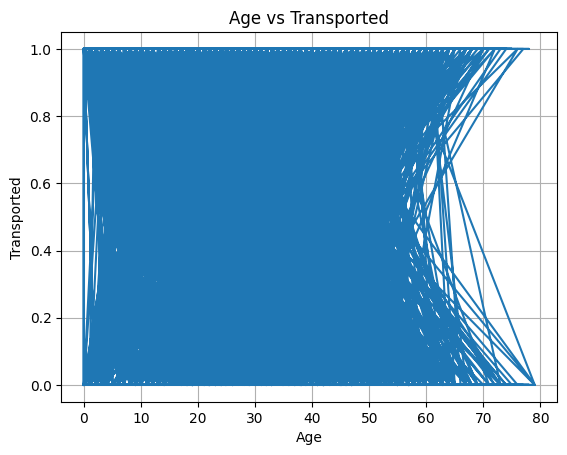

In [16]:
# checking for "Age" column
plt.figure()
# plt.scatter(x= train["Age"],y= train["Transported"])
plt.plot(train["Age"],train["Transported"])
plt.grid(True)
plt.xlabel("Age")
plt.ylabel("Transported")
plt.title("Age vs Transported")
plt.show()
# by graph, age column doesnt really seem that imp to be considered into training

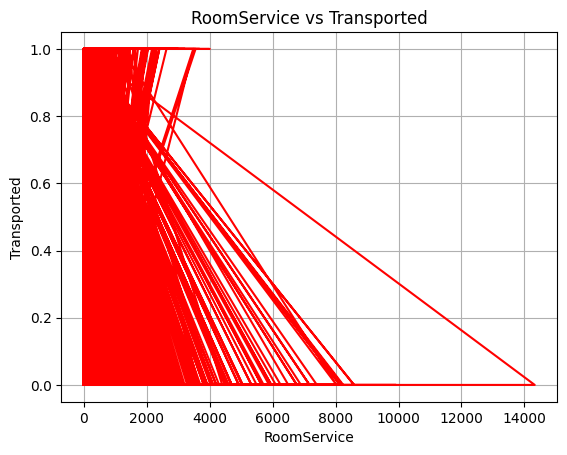

In [17]:
# checking for "RoomService" column
plt.figure()
plt.plot(train["RoomService"],train["Transported"], color='r')
plt.grid(True)
plt.xlabel("RoomService")
plt.ylabel("Transported")
plt.title("RoomService vs Transported")
plt.show()

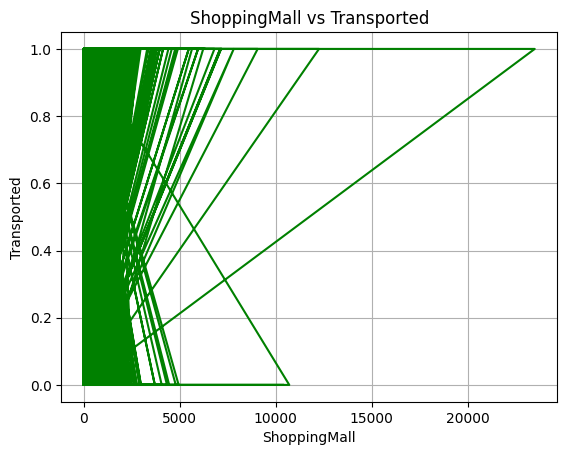

In [18]:
# checking for "ShoppingMall" column
plt.figure()
plt.plot(train["ShoppingMall"],train["Transported"],color='g')
plt.grid(True)
plt.xlabel("ShoppingMall")
plt.ylabel("Transported")
plt.title("ShoppingMall vs Transported")
plt.show()

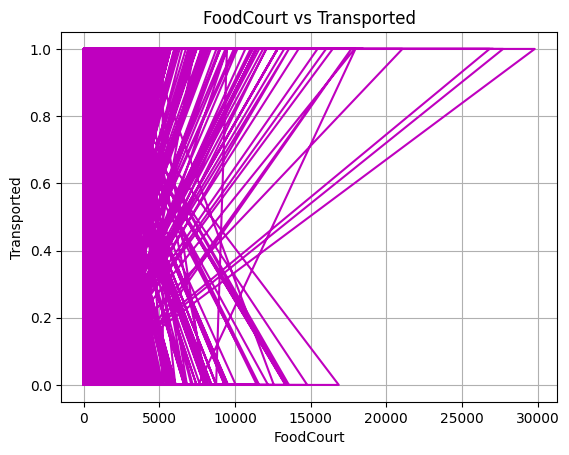

In [19]:
# checking for "FoodCourt" column
plt.figure()
# plt.scatter(x= train["FoodCourt"],y= train["Transported"])
plt.plot(train["FoodCourt"],train["Transported"],color='m')
plt.grid(True)
plt.xlabel("FoodCourt")
plt.ylabel("Transported")
plt.title("FoodCourt vs Transported")
plt.show()

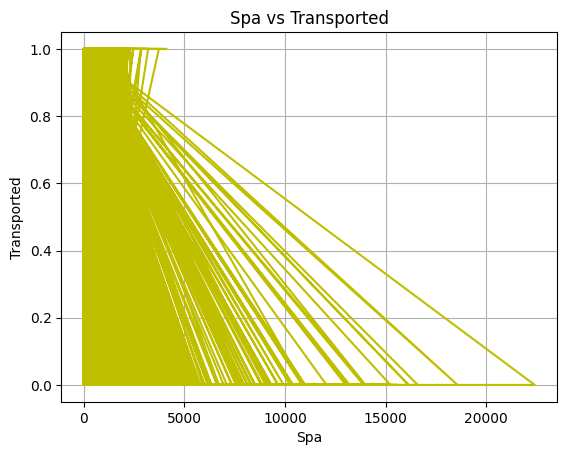

In [20]:
# checking for "Spa" column
plt.figure()
# plt.scatter(x= train["Spa"],y= train["Transported"])
plt.plot(train["Spa"],train["Transported"],color='y')
plt.grid(True)
plt.xlabel("Spa")
plt.ylabel("Transported")
plt.title("Spa vs Transported")
plt.show()

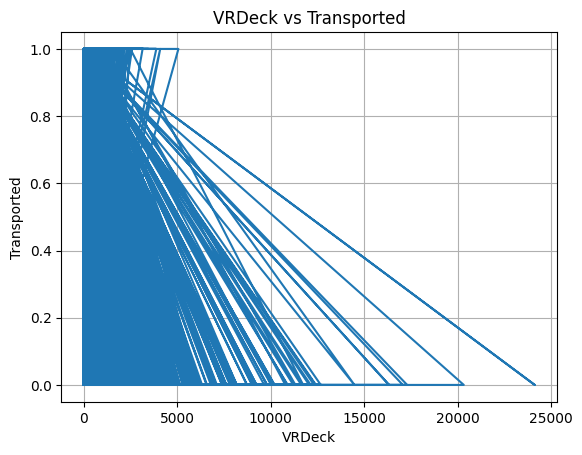

In [21]:
# checking for "VRDeck" column
plt.figure()
plt.plot(train["VRDeck"],train["Transported"])
plt.grid(True)
plt.xlabel("VRDeck")
plt.ylabel("Transported")
plt.title("VRDeck vs Transported")
plt.show()

In [22]:
# checking for "Cabin" column
# plt.figure()
# sns.barplot(x=train["Cabin"],y=train["Transported"])
# plt.grid(True)
# plt.xlabel("Cabin")
# plt.ylabel("Transported")
# plt.title("Cabin vs Transported")
# plt.show()

# doubt- yaha to i actually know ki cabin ek useless column ho skta h, but what if its useful, then how will i include an aplhanumeric column into fit function??

In [23]:
# now checking for relation of categorical data columns with the 'Transported' column

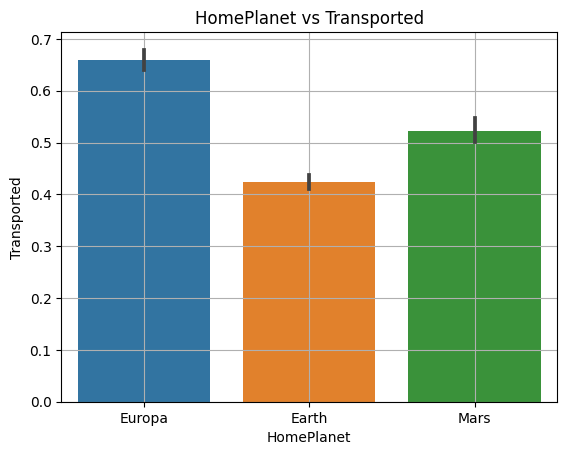

In [24]:
# checking for "HomePlanet" column
plt.figure()
sns.barplot(x= train["HomePlanet"],y= train["Transported"])
plt.grid(True)
plt.xlabel("HomePlanet")
plt.ylabel("Transported")
plt.title("HomePlanet vs Transported")
plt.show()

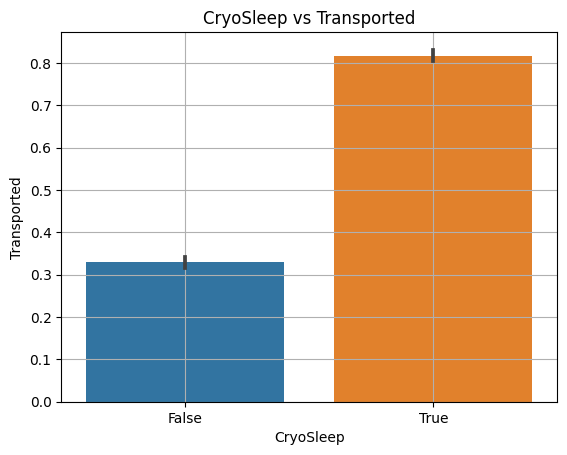

In [25]:
# checking for "CryoSleep" column
plt.figure()
sns.barplot(x= train["CryoSleep"],y= train["Transported"])
plt.grid(True)
plt.xlabel("CryoSleep")
plt.ylabel("Transported")
plt.title("CryoSleep vs Transported")
plt.show()

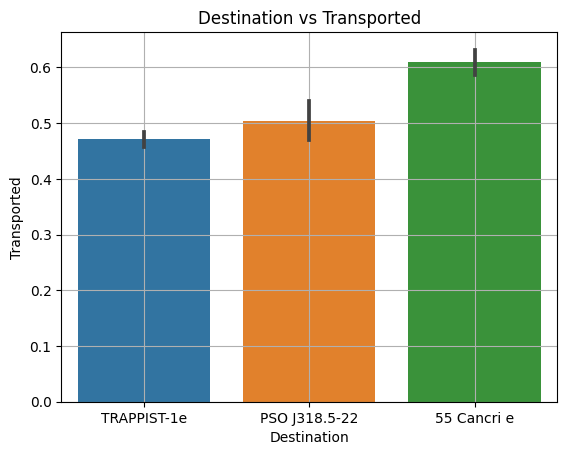

In [26]:
# checking for "Destination" column
plt.figure()
sns.barplot(x= train["Destination"],y= train["Transported"])
plt.grid(True)
plt.xlabel("Destination")
plt.ylabel("Transported")
plt.title("Destination vs Transported")
plt.show()

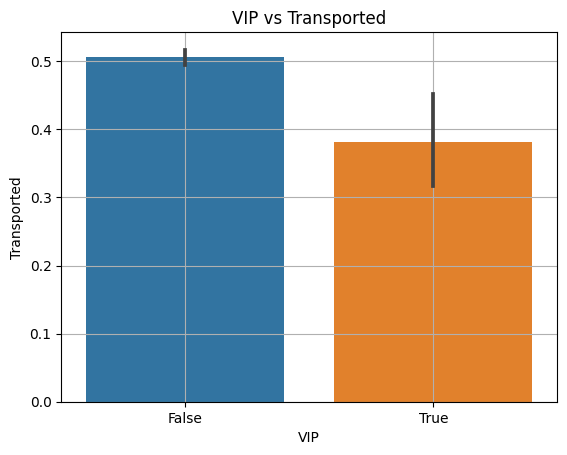

In [27]:
# checking for "VIP" column
plt.figure()
sns.barplot(x= train["VIP"],y= train["Transported"])
plt.grid(True)
plt.xlabel("VIP")
plt.ylabel("Transported")
plt.title("VIP vs Transported")
plt.show()

In [28]:
# encoding desired categorical data now:
from sklearn.preprocessing import LabelEncoder
encoder= LabelEncoder()

In [29]:
# making encoder for "HomePlanet"
train["HomePlanet_label"]= encoder.fit_transform(train["HomePlanet"])
{class_:index for index, class_ in enumerate(encoder.classes_)}

{'Earth': 0, 'Europa': 1, 'Mars': 2, nan: 3}

In [30]:
test["HomePlanet_label"]= encoder.fit_transform(test["HomePlanet"])
{class_:index for index, class_ in enumerate(encoder.classes_)}

{'Earth': 0, 'Europa': 1, 'Mars': 2, nan: 3}

In [31]:
# making encoder for "CryoSleep"
train["CryoSleep_label"]= encoder.fit_transform(train["CryoSleep"])
{class_:index for index, class_ in enumerate(encoder.classes_)}

{False: 0, True: 1, nan: 2}

In [32]:
test["CryoSleep_label"]= encoder.fit_transform(test["CryoSleep"])
{class_:index for index, class_ in enumerate(encoder.classes_)}

{False: 0, True: 1, nan: 2}

In [33]:
# making encoder for "Destination"
train["Destination_label"]= encoder.fit_transform(train["Destination"])
{class_:index for index, class_ in enumerate(encoder.classes_)}

{'55 Cancri e': 0, 'PSO J318.5-22': 1, 'TRAPPIST-1e': 2, nan: 3}

In [34]:
test["Destination_label"]= encoder.fit_transform(test["Destination"])
{class_:index for index, class_ in enumerate(encoder.classes_)}

{'55 Cancri e': 0, 'PSO J318.5-22': 1, 'TRAPPIST-1e': 2, nan: 3}

In [35]:
# making encoder for "VIP"
train["VIP_label"]= encoder.fit_transform(train["VIP"])
{class_:index for index, class_ in enumerate(encoder.classes_)}

{False: 0, True: 1, nan: 2}

In [36]:
test["VIP_label"]= encoder.fit_transform(test["VIP"])
{class_:index for index, class_ in enumerate(encoder.classes_)}

{False: 0, True: 1, nan: 2}

In [37]:
# now training our ML model based on the train dataframe

In [38]:
from sklearn.linear_model import LogisticRegression
lReg= LogisticRegression()
lReg.fit(train[["HomePlanet_label","CryoSleep_label","Destination_label","VIP_label","RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]],train["Transported"])

LogisticRegression()

In [39]:
y_predict= lReg.predict(test[["HomePlanet_label","CryoSleep_label","Destination_label","VIP_label","RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]])

In [40]:
# submission=pd.DataFrame()
submission = pd.DataFrame({"PassengerId": test["PassengerId"],"Transported": y_predict})


In [41]:
submission["Transported"]=np.where(submission["Transported"]>=0.65,True,False)

In [42]:
submission

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
...,...,...
4272,9266_02,True
4273,9269_01,True
4274,9271_01,True
4275,9273_01,True


In [43]:
submission.to_csv('submission.csv', index=False)